### Built a basic chatbot with Langgraph (GRAPH API)


In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
  

In [2]:
# creating a state that is actually a shared memory by all the nodes 
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
  

In [3]:
import os
from dotenv import load_dotenv,find_dotenv
load_dotenv(find_dotenv())

True

In [4]:
#.chat_models import init_chat_model

# using chatgroq
from langchain_groq import ChatGroq
llm = ChatGroq(model="llma3-8b-8192")


#using init_chat_model
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llma3-8b-8192")

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x0000020E892D5950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020E892D6350>, model_name='llma3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# creating a node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder =StateGraph(State)

#adding node to the graph

graph_builder.add_node("LLmChatbot", chatbot)

# Adding edges

graph_builder.add_edge(START,"LLmChatbot")
graph_builder.add_edge("LLmChatbot",END)

#compile the graph
graph = graph_builder.compile()

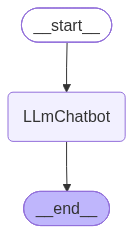

In [9]:
# visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass